## Customer Revenue Prediction

#### We will predict that how much a customer can generate over his purchasing behavior

In [1]:
# ==========================
# Data Manipulation
# ==========================

import pandas as pd
import numpy as np

# ==========================
# Data Visualization
# ==========================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# Machine Learning
# ==========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
df = pd.read_csv(r"C:\Users\amit6\OneDrive\Desktop\Intelligent-Retail-Customer-Analytics\Data\Processed_data\customer_feature_store.csv")
df.head()

,CustomerID,Frequency,TotalQuantity,Revenue,FirstPurchase,LastPurchase,AverageUnitPrice,UniqueProducts,Country,CustomerTenure,Recency,AverageOrderValue,AverageQuantityPerOrder,WeekendPurchaseRatio,ReturnRate,AverageDaysBetweenOrders
0,12346.0,12,74285,77556.46,2009-12-14 08:34:00,2011-01-18 10:01:00,6.100000,27,United Kingdom,400,325,6463.038333,6190.416667,0.000000,0.0,35.909091
1,12347.0,8,2967,4921.53,2010-10-31 14:20:00,2011-12-07 15:52:00,2.498063,126,Iceland,402,1,615.191250,370.875000,0.180180,0.0,57.000000
2,12348.0,5,2714,2019.40,2010-09-27 14:59:00,2011-09-25 13:13:00,3.786275,25,Finland,362,74,403.880000,542.800000,0.058824,0.0,90.500000
3,12349.0,4,1624,4428.69,2010-04-29 13:20:00,2011-11-21 09:51:00,8.459657,138,Italy,570,18,1107.172500,406.000000,0.000000,0.0,189.666667
4,12350.0,1,197,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,3.841176,17,Norway,0,309,334.400000,197.000000,0.000000,0.0,0.000000


In [3]:
df.isnull().sum()

CustomerID                  0
Frequency                   0
TotalQuantity               0
Revenue                     0
FirstPurchase               0
LastPurchase                0
AverageUnitPrice            0
UniqueProducts              0
Country                     0
CustomerTenure              0
Recency                     0
AverageOrderValue           0
AverageQuantityPerOrder     0
WeekendPurchaseRatio        0
ReturnRate                  0
AverageDaysBetweenOrders    0
dtype: int64

In [4]:
X = df.drop(
    columns=[
        "CustomerID",
        "Revenue",
        "FirstPurchase",
        "LastPurchase"
    ]
)

In [5]:
y = df["Revenue"]

In [6]:
encoder = LabelEncoder()
X["Country"] = encoder.fit_transform(X["Country"])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
X,y,test_size=0.20,random_state=42
)

In [8]:
print(X_train.shape)
print(X_test.shape)

(4702, 12)
(1176, 12)


In [9]:
rf = RandomForestRegressor(
n_estimators=300,max_depth=10,random_state=42,n_jobs=-1
)

In [10]:
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [12]:
print("="*40)
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")
print("="*40)

MAE  : 740.61
MSE  : 85936455.16
RMSE : 9270.19
R² Score : 0.7633


In [20]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False
)
importance.to_csv(
    "feature_importance.csv",
    index=False
)

print(importance) 

print(importance)

                     Feature  Importance
1              TotalQuantity    0.672090
5             CustomerTenure    0.141208
6                    Recency    0.040718
2           AverageUnitPrice    0.038567
0                  Frequency    0.026949
7          AverageOrderValue    0.024374
3             UniqueProducts    0.021621
11  AverageDaysBetweenOrders    0.014791
8    AverageQuantityPerOrder    0.011903
9       WeekendPurchaseRatio    0.005027
4                    Country    0.002753
10                ReturnRate    0.000000
                     Feature  Importance
1              TotalQuantity    0.672090
5             CustomerTenure    0.141208
6                    Recency    0.040718
2           AverageUnitPrice    0.038567
0                  Frequency    0.026949
7          AverageOrderValue    0.024374
3             UniqueProducts    0.021621
11  AverageDaysBetweenOrders    0.014791
8    AverageQuantityPerOrder    0.011903
9       WeekendPurchaseRatio    0.005027
4               

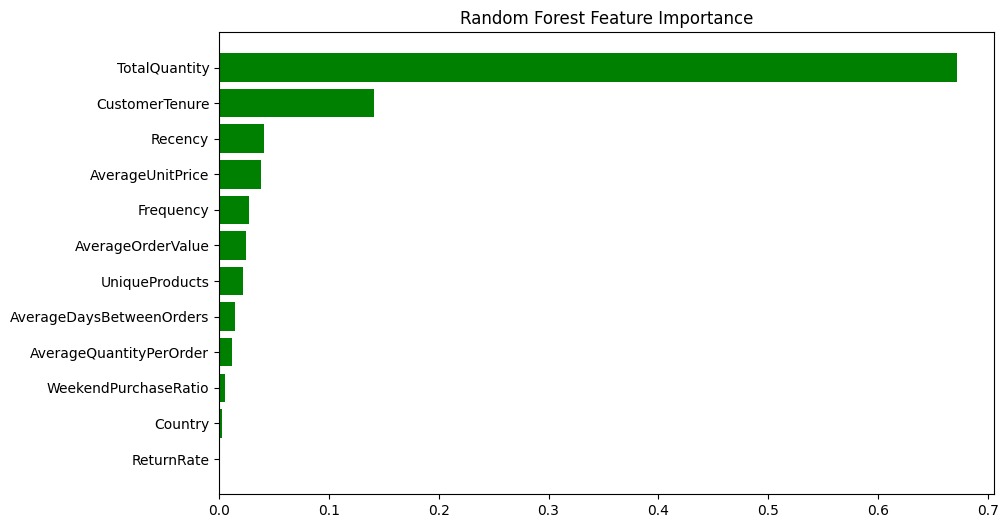

In [14]:
plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"],

    importance["Importance"], color = 'green'

)

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

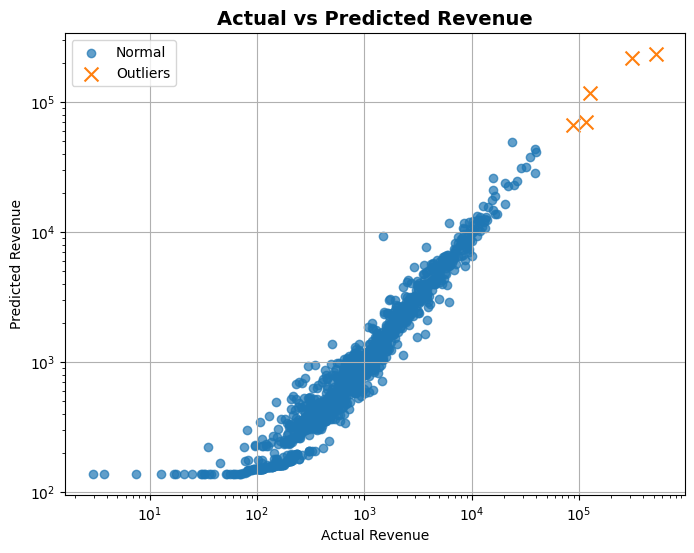

In [15]:
threshold = 50000

plt.figure(figsize=(8,6))

# Normal points
plt.scatter(
    y_test[y_test < threshold],
    y_pred[y_test < threshold],
    alpha=0.7,
    label='Normal'
)

plt.xscale('log')
plt.yscale('log')
# Outliers
plt.scatter(
    y_test[y_test >= threshold],
    y_pred[y_test >= threshold],
    marker='x',
    s=100,
    label='Outliers'
)

plt.xlabel("Actual Revenue")

plt.ylabel("Predicted Revenue")

plt.title("Actual vs Predicted Revenue",fontsize = 14, weight = 'bold')

plt.legend()
plt.grid(True)

plt.show()

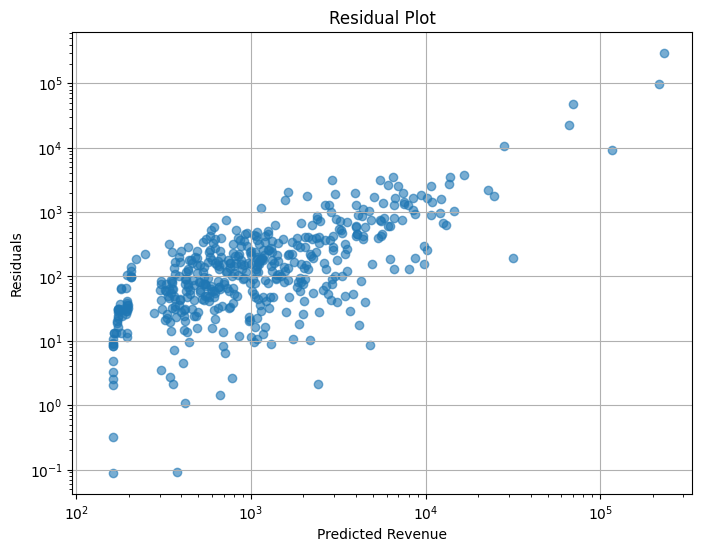

In [16]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [17]:
joblib.dump(
    rf,
    "RandomForest_Revenue_Model.pkl"
)

['RandomForest_Revenue_Model.pkl']

In [18]:
comparison = pd.DataFrame({
    "ActualRevenue": y_test,
    "PredictedRevenue": y_pred
})

comparison.to_csv(
    "actual_vs_predicted.csv",
    index=False
)

In [19]:
import pandas as pd

comparison = pd.DataFrame({
    "ActualRevenue": y_test,
    "PredictedRevenue": y_pred
})

# Remove top 1% extreme values
q = comparison["ActualRevenue"].quantile(0.99)

comparison_visual = comparison[
    comparison["ActualRevenue"] <= q
]

comparison_visual.to_csv(
    "actual_vs_predicted_visual.csv",
    index=False
)